In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from config import DATA_PROCESSED, OUTPUTS_DIR, FICO_LABELS

# Consistent visual style across all dissertation charts
plt.rcParams.update({
    "figure.dpi"      : 150,
    "axes.spines.top" : False,
    "axes.spines.right": False,
    "axes.grid"       : True,
    "grid.alpha"      : 0.3,
    "font.size"       : 11,
})

OUTPUTS_DIR.mkdir(exist_ok=True)

df = pd.read_parquet(DATA_PROCESSED / "model_dataset.parquet")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns:\n{df.dtypes}")

Matplotlib is building the font cache; this may take a moment.


Dataset shape: (4464305, 36)

Columns:
credit_score                              float64
first_payment_date                         object
first_time_homebuyer                       object
maturity_date                              object
msa                                        object
mip                                        object
num_units                                  object
occupancy_status                           object
cltv                                       object
dti                                       float64
orig_upb                                  float64
oltv                                      float64
orig_interest_rate                        float64
channel                                    object
prepay_penalty                             object
amortization_type                          object
property_state                             object
property_type                              object
postal_code                                object
loan_sequen

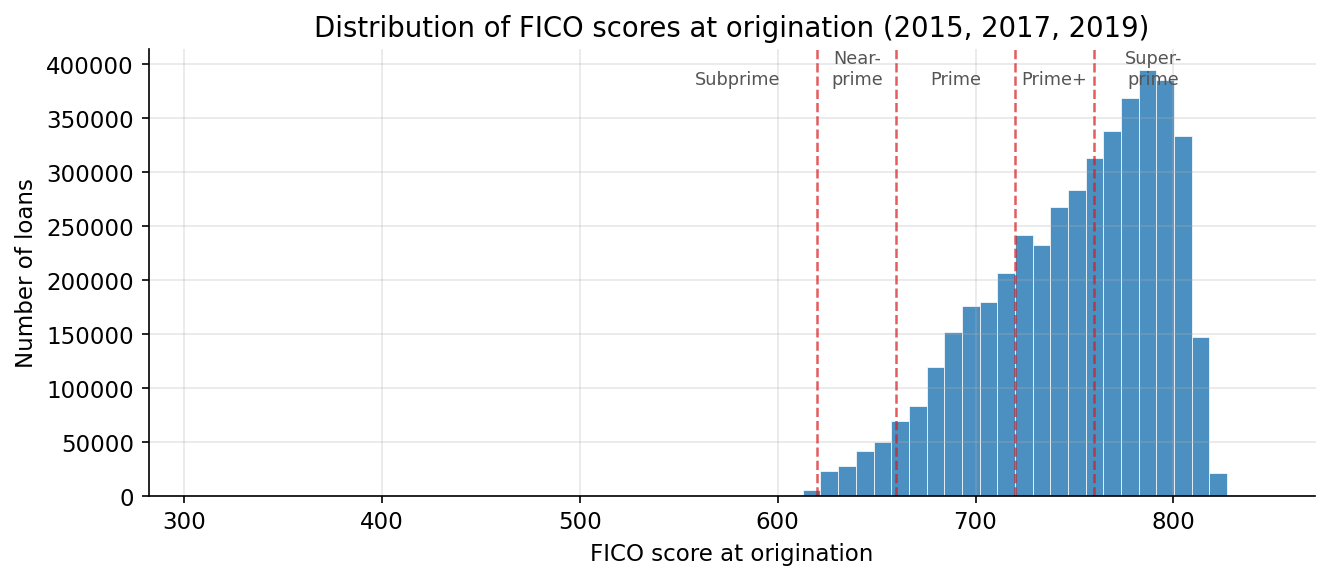

Saved fig1_fico_distribution.png


In [2]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(
    df["credit_score"],
    bins=60,
    color="#2c7bb6",
    edgecolor="white",
    linewidth=0.4,
    alpha=0.85,
)

# Mark the FICO band cutoff lines
for cutoff in [620, 660, 720, 760]:
    ax.axvline(cutoff, color="#d7191c", linewidth=1.2, linestyle="--", alpha=0.7)

ax.set_xlabel("FICO score at origination")
ax.set_ylabel("Number of loans")
ax.set_title("Distribution of FICO scores at origination (2015, 2017, 2019)")

# Annotate band labels along the top
band_centres = [580, 640, 690, 740, 790]
band_names   = ["Subprime", "Near-\nprime", "Prime", "Prime+", "Super-\nprime"]
for x, name in zip(band_centres, band_names):
    ax.text(x, ax.get_ylim()[1] * 0.92, name,
            ha="center", fontsize=8.5, color="#555555")

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "fig1_fico_distribution.png", bbox_inches="tight")
plt.show()
print("Saved fig1_fico_distribution.png")

Default rate by FICO band:
           fico_band   loans  defaults  default_rate_pct
     <620 (subprime)    2723       354         13.000367
620–659 (near-prime)  158929     22492         14.152231
     660–719 (prime)  975271     83640          8.576078
    720–759 (prime+) 1163071     58287          5.011474
  760+ (super-prime) 2164311     50898          2.351695


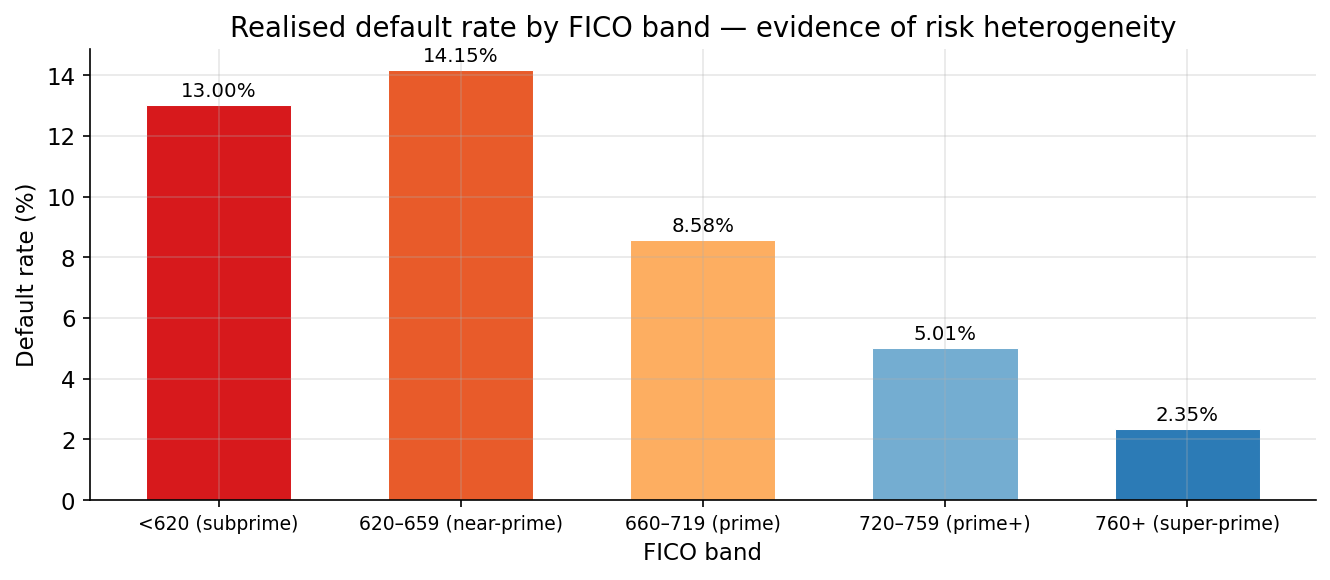

In [3]:
band_stats = (
    df.groupby("fico_band", observed=True)["ever_defaulted"]
    .agg(
        loans="count",
        defaults="sum",
        default_rate="mean",
    )
    .reset_index()
)

band_stats["default_rate_pct"] = band_stats["default_rate"] * 100

print("Default rate by FICO band:")
print(band_stats[["fico_band", "loans", "defaults", "default_rate_pct"]]
      .to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))

colours = ["#d7191c", "#e85b2a", "#fdae61", "#74add1", "#2c7bb6"]
bars = ax.bar(
    band_stats["fico_band"].astype(str),
    band_stats["default_rate_pct"],
    color=colours,
    edgecolor="white",
    linewidth=0.5,
    width=0.6,
)

# Label each bar with the exact rate
for bar, rate in zip(bars, band_stats["default_rate_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{rate:.2f}%",
        ha="center", va="bottom", fontsize=9.5
    )

# Draw the 72.5% output floor reference — not needed yet but
# orient your reader to what's coming
ax.set_xlabel("FICO band")
ax.set_ylabel("Default rate (%)")
ax.set_title("Realised default rate by FICO band — evidence of risk heterogeneity")
ax.tick_params(axis="x", labelsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "fig2_default_rate_by_fico.png", bbox_inches="tight")
plt.show()

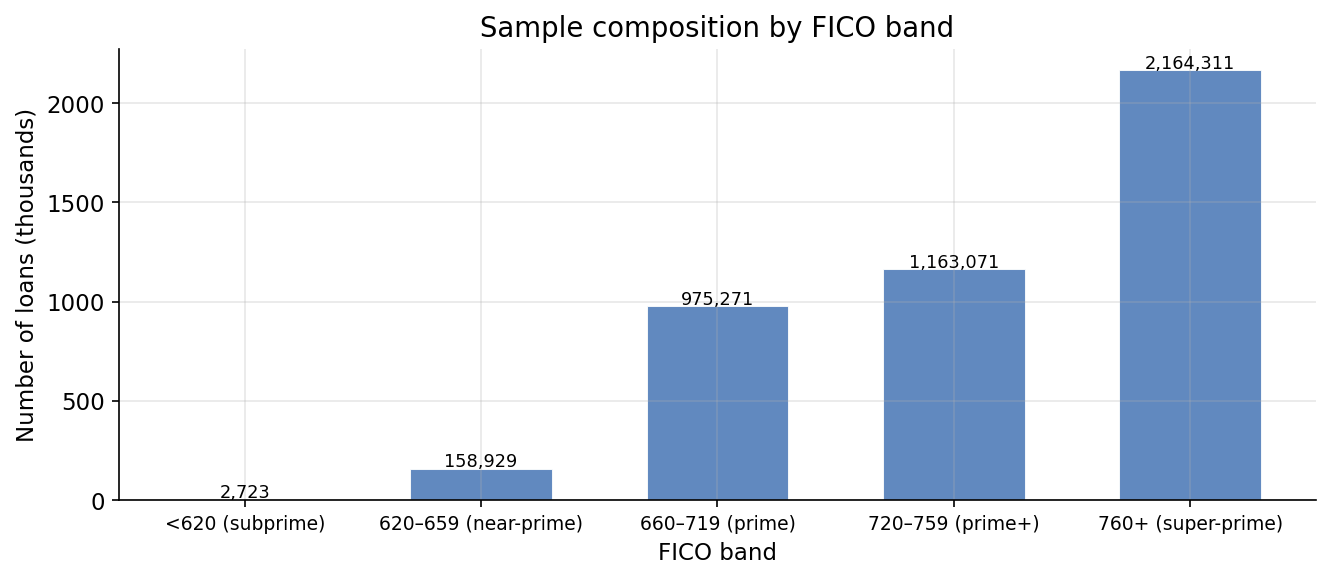

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    band_stats["fico_band"].astype(str),
    band_stats["loans"] / 1_000,
    color="#4575b4",
    edgecolor="white",
    linewidth=0.5,
    width=0.6,
    alpha=0.85,
)

for i, (_, row) in enumerate(band_stats.iterrows()):
    ax.text(i, row["loans"] / 1_000 + 10,
            f"{row['loans']:,.0f}",
            ha="center", fontsize=8.5)

ax.set_xlabel("FICO band")
ax.set_ylabel("Number of loans (thousands)")
ax.set_title("Sample composition by FICO band")
ax.tick_params(axis="x", labelsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "fig3_loan_count_by_fico.png", bbox_inches="tight")
plt.show()

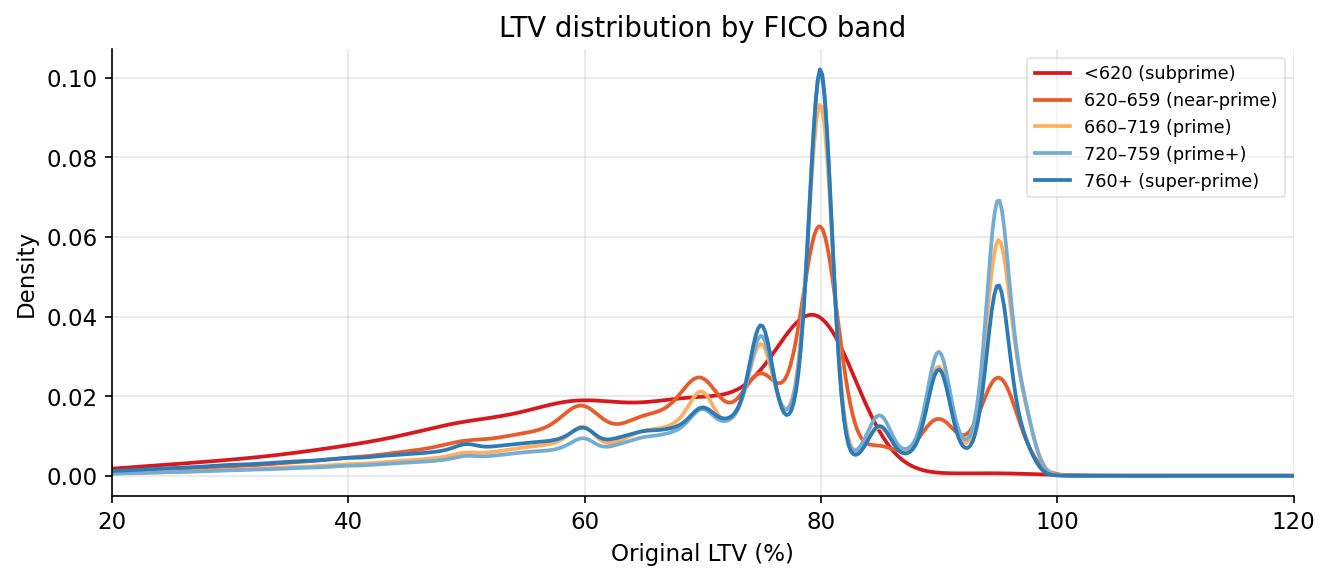

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))

for band, colour in zip(FICO_LABELS, ["#d7191c","#e85b2a","#fdae61","#74add1","#2c7bb6"]):
    subset = df[df["fico_band"] == band]["oltv"].dropna()
    subset.plot.kde(ax=ax, label=band, color=colour, linewidth=1.8)

ax.set_xlabel("Original LTV (%)")
ax.set_ylabel("Density")
ax.set_title("LTV distribution by FICO band")
ax.set_xlim(20, 120)
ax.legend(fontsize=8.5, framealpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "fig4_ltv_by_fico.png", bbox_inches="tight")
plt.show()

In [6]:
summary_cols = ["credit_score", "oltv", "dti", "orig_upb", "ever_defaulted"]

summary_table = (
    df[summary_cols]
    .describe(percentiles=[0.25, 0.50, 0.75])
    .T
    .round(2)
)

summary_table.index = [
    "FICO score", "Original LTV (%)",
    "DTI (%)", "Original UPB (USD)", "Ever defaulted (0/1)"
]

print("Summary statistics table (copy into dissertation):")
print(summary_table.to_string())

# Save as CSV for easy pasting into Word/LaTeX
summary_table.to_csv(OUTPUTS_DIR / "table1_summary_stats.csv")
print("\nSaved table1_summary_stats.csv")

Summary statistics table (copy into dissertation):
                          count       mean        std     min       25%       50%       75%        max
FICO score            4464305.0     749.70      44.46   309.0     719.0     758.0     787.0      845.0
Original LTV (%)      4464305.0      74.98      16.64     1.0      67.0      80.0      87.0      117.0
DTI (%)               4464305.0      34.74       9.38     1.0      28.0      36.0      42.0       61.0
Original UPB (USD)    4464305.0  242151.56  125224.29  1000.0  146000.0  220000.0  320000.0  1397000.0
Ever defaulted (0/1)  4464305.0       0.05       0.21     0.0       0.0       0.0       0.0        1.0

Saved table1_summary_stats.csv


Default rate by origination year:
 orig_year   loans  default_rate  default_rate_pct
      2015 1352773      0.036524          3.652424
      2017 1332347      0.054741          5.474099
      2019 1779185      0.052455          5.245548


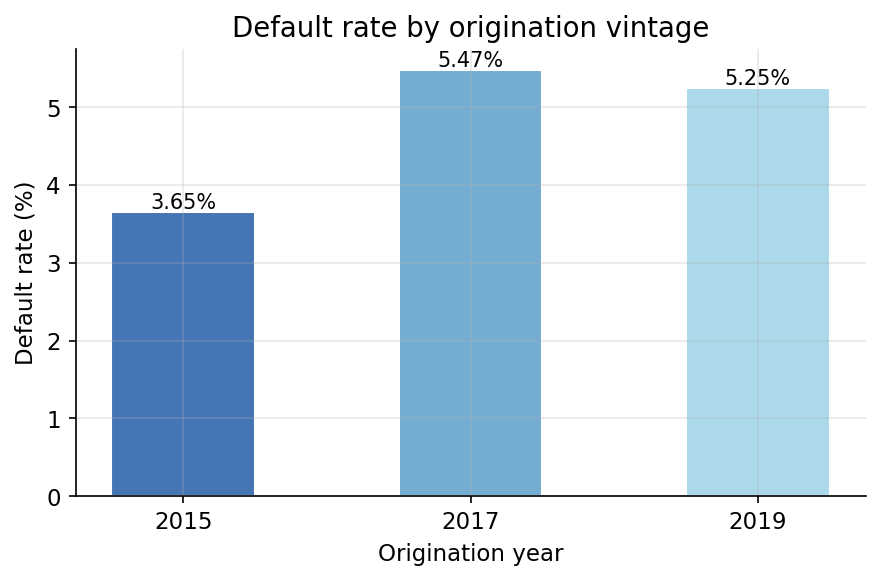

In [7]:
vintage_stats = (
    df.groupby("orig_year")["ever_defaulted"]
    .agg(loans="count", default_rate="mean")
    .reset_index()
)
vintage_stats["default_rate_pct"] = vintage_stats["default_rate"] * 100

print("Default rate by origination year:")
print(vintage_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    vintage_stats["orig_year"].astype(str),
    vintage_stats["default_rate_pct"],
    color=["#4575b4", "#74add1", "#abd9e9"],
    edgecolor="white", width=0.5
)
for i, row in vintage_stats.iterrows():
    ax.text(i, row["default_rate_pct"] + 0.05,
            f"{row['default_rate_pct']:.2f}%",
            ha="center", fontsize=10)

ax.set_xlabel("Origination year")
ax.set_ylabel("Default rate (%)")
ax.set_title("Default rate by origination vintage")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "fig5_default_rate_by_vintage.png", bbox_inches="tight")
plt.show()